In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import dbof.global_dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.global_dataset_creation.zarr_grid_global    as zarr_grid
import dbof.io.filesystems as filesystems

from dbof.global_dataset_creation.subset_definitions import get_subset_definition
from dbof.global_dataset_creation.subset_definitions import expand_channels_with_suffixes

# Assess GLOBAL dataset (`generate-global`)

This notebook inspects any subset written by `generate-global`.

**IMPORTANT: `SUBSET` must be valid for the `pipeline` set in
`configs/global/data_access/access.yaml`.**  See `configs/global/run/run.yaml` for the
full pipeline × subset mapping.
- If `pipeline = SURF` or `OSN` → use a **Surface subset** only.
- If `pipeline = DEPTH` → use a **Depth subset** only.

All subsets are surface-level `(T, C, H, W)` and use `GlobalZarrDatasetReader`.
For the DEPTH pipeline, depth-derived diagnostics are computed lazily from the
full water column and reduced to 2D before writing — the Zarr stores contain
only surface fields.

### Depth suffixes (DEPTH pipeline)
Fields with depth variants use the suffixes:
- `_sfc` — z = 0 (surface, k=0)
- `_z25m` — z = 25 m (fixed depth)
- `_mld` — interpolated to the mixed-layer depth
- `_mld_mean` — thickness-weighted mean over 0 <= z <= MLD

### Surface subsets (SURF / OSN)

| Subset | Channels | Output zarr |
|---|---|---|
| `native_fields` | `Theta`, `Salt`, `Eta`, `W`, `U`, `V` (U/V rotated to eastward/northward) | `native_fields.zarr` |
| `surface_wind` | `oceTAUX`, `oceTAUY` (eastward/northward), `wind_stress_curl`, `ekman_pumping`, `u/v_ekman` (+ `oceQnet`, SURF only) | `surface_wind.zarr` |
| `icearea` | `SIarea` | `icearea.zarr` |
| `frontal_structure` | `gradsalt2`, `gradtheta2`, `gradeta2`, `gradb2`, `gradrho2`, `turner_angle`, `density`, `buoyancy` | `frontal_structure.zarr` |
| `kinematic` | `relative_vorticity`, `strain_n/s`, `strain_mag`, `divergence`, `coriolis_f`, `rossby_number`, `okubo_weiss` | `kinematic.zarr` |
| `frontogenesis` | `frontogenesis_tendency`, `ug`, `vg`, `frontogenesis_geo`, `frontogenesis_ageo` | `frontogenesis.zarr` |

### Depth subsets (DEPTH)

| Subset | Channels | Output zarr |
|---|---|---|
| `stratification` | `mixed_layer_depth`, `N2_sfc/z25m/mld/mld_mean`, `ml_heat_content` | `stratification.zarr` |
| `vertical_shear` | `vertical_shear_sfc/z25m/mld/mld_mean`, `Ri_sfc/z25m/mld/mld_mean` | `vertical_shear.zarr` |
| `mixing_parameters` | `Fr/Ro/Bu_sfc/z25m/mld/mld_mean` | `mixing_parameters.zarr` |
| `ertel_pv` | `ertel_pv[_vertical/_tilt]_sfc/z25m/mld/mld_mean` (12 channels) | `ertel_pv.zarr` |
| `buoyancy_fluxes` | `uB/vB/wB_sfc/z25m/mld/mld_mean` (12 channels) | `buoyancy_fluxes.zarr` |
| `surface_wind` | `wind_stress_curl`, `ekman_pumping`, `u/v_ekman`, `oceTAUX/Y`, `oceQnet` | `surface_wind.zarr` |
| `energetics` | `KE_sfc/z25m/mld/mld_mean` | `energetics.zarr` |
| `native_fields` | `Theta/Salt/U/V/W` x depths, `Eta_sfc` (U/V eastward/northward) | `native_fields.zarr` |
| `icearea` | `SIarea` | `icearea.zarr` |
| `frontal_structure` | gradient fields x depths | `frontal_structure.zarr` |
| `kinematic` | vorticity/strain fields x depths | `kinematic.zarr` |
| `frontogenesis` | frontogenesis fields x depths | `frontogenesis.zarr` |


## Dataset access config

Parameters are loaded from `configs/global/data_access/access.yaml`.
Update `run_id` and `date_prefix` in that file to match the session you want
to inspect.

In [13]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
# ════════════════════════════════════════════════════════════════════════════════
# Set SUBSET to any valid subset for the pipeline.
#
# Depth subsets (DEPTH pipeline):
#   'stratification', 'vertical_shear', 'mixing_parameters', 'ertel_pv',
#   'buoyancy_fluxes', 'surface_wind', 'energetics',
#   'frontal_structure', 'kinematic', 'frontogenesis',
#   'native_fields', 'icearea'
#
# Surface subsets (SURF / OSN pipeline):
#   'native_fields', 'frontal_structure', 'kinematic', 'frontogenesis'
# ════════════════════════════════════════════════════════════════════════════════
SUBSET = 'icearea'  # <-- update this for each run
# ════════════════════════════════════════════════════════════════════════════════

# --- Load YAML (S3 coordinates only — no variable lists) ---
path_to_config = "../../configs/global/data_access/access.yaml"
with open(path_to_config) as f:
    cfg = yaml.safe_load(f)

pipeline = cfg.get("pipeline", "DEPTH")

data_cfg = cfg["data_access"]
grid_cfg = cfg["grid_access"]

bucket      = data_cfg["bucket"]
folder      = data_cfg["folder"]
s3_endpoint = data_cfg["s3_endpoint"]
run_id      = data_cfg["run_id"]
date_prefix = data_cfg["date_prefix"]

# --- Get channel lists from code (single source of truth) ---
defn = get_subset_definition(pipeline, SUBSET)

dataset_name   = defn["dataset_name"]
model_channels = list(defn["model_data_feature_channels"])

# Depth suffixes: YAML override > subset definition default.
# Only apply when the subset definition itself declares depth_suffixes —
# surface subsets must never get suffixes.  Mirrors generate_global.py.
yaml_depth_suffixes = cfg.get("depth_suffixes")
defn_suffixes = defn.get("depth_suffixes")
depth_suffixes = (yaml_depth_suffixes or defn_suffixes) if defn_suffixes is not None else None

# Expand compute channels with depth suffixes.
compute_channels = expand_channels_with_suffixes(
    defn["compute_features_channels"],
    depth_suffixes=depth_suffixes,
    extra_channels=defn.get("extra_channels"),
)
all_channels = model_channels + compute_channels

grid_bucket       = grid_cfg["bucket"]
grid_folder       = grid_cfg["folder"]
grid_s3_endpoint  = grid_cfg["s3_endpoint"]
grid_dataset_name = grid_cfg["dataset_name"]

print(f"Pipeline      : {pipeline}")
print(f"Subset        : {SUBSET}")
print(f"Snapshot      : s3://{bucket}/{folder}/{run_id}/{date_prefix}/{dataset_name}")
if depth_suffixes:
    src = "YAML override" if yaml_depth_suffixes else "code default"
    print(f"Depth suffixes: {depth_suffixes}  ({src})")
print(f"Model channels: {model_channels}")
print(f"Compute chans : {compute_channels}")
print(f"All channels  : {all_channels}")
print(f"Grid          : s3://{grid_bucket}/{grid_folder}/{grid_dataset_name}")

Pipeline      : SURF
Subset        : icearea
Snapshot      : s3://dbof/surface_fields/vtest/20120501_120000/icearea.zarr
Model channels: ['SIarea']
Compute chans : []
All channels  : ['SIarea']
Grid          : s3://dbof/native_grid_dbof_training_data/llc4320_grid.zarr


# Load the data

In [14]:
# ── Reader ──────────────────────────────────────────────────────────────────────
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name=dataset_name,
    date_prefix=date_prefix,
    fs=fs,
)
print(reader)
print(f"Channels  : {reader.channel_names}")
print(f"Shape     : {reader.shape}  (C, H, W)")

# ── Grid reader ────────────────────────────────────────────────────────────────
fs_grid, _ = filesystems.create_s3_filesystems(grid_s3_endpoint)

grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=grid_bucket,
    folder=grid_folder,
    dataset_name=grid_dataset_name,
    fs=fs_grid,
)
print(grid_reader)

XC = grid_reader.lon
YC = grid_reader.lat
print(f"Grid loaded: XC {XC.shape}, lon [{XC.min():.1f}, {XC.max():.1f}]  "
      f"YC {YC.shape}, lat [{YC.min():.1f}, {YC.max():.1f}]")

DS_GLOBAL = 20
XC_g = XC[::DS_GLOBAL, ::DS_GLOBAL]
YC_g = YC[::DS_GLOBAL, ::DS_GLOBAL]

Channels  : ['SIarea']
Shape     : (1, 12960, 17280)  (C, H, W)
GlobalGridZarrReader(shape=(12960, 17280), variables=['XC', 'YC', 'rA', 'Depth', 'SN', 'CS', 'hFacC', 'dxC', 'dyG', 'hFacW', 'rAw', 'dyC', 'dxG', 'hFacS', 'rAs', 'rAz', 'XG', 'YG', 'lat', 'lon'])
Grid loaded: XC (12960, 17280), lon [-180.0, 180.0]  YC (12960, 17280), lat [-90.0, 72.0]


In [15]:
print(f"iteration : {reader.iteration}")

iteration : 810432


# Colormap / label configuration

All channels are registered here.  Only channels present in the selected subset
will be plotted.

In [16]:
# ── Colormap and physical label registry ──────────────────────────────────────
# Single source of truth, shared across notebooks (src/dbof/plotting/field_cmaps.yaml).
# cmo colormaps: https://matplotlib.org/cmocean/
from dbof.plotting.field_cmaps import load_field_cmaps
from dbof.plotting.global_maps import plot_global_field

CMAP_CFG, DIVERGING_CMAPS = load_field_cmaps()

channels_to_plot = [ch for ch in reader.channel_names if ch in CMAP_CFG]
print(f"Plotting {len(channels_to_plot)} / {len(reader.channel_names)} channels")
if len(channels_to_plot) < len(reader.channel_names):
    missing = [ch for ch in reader.channel_names if ch not in CMAP_CFG]
    print(f"  (missing from CMAP_CFG: {missing})")

# Channels that should use a logarithmic colour scale.
LOG_SCALE_CHANNELS = {k for k in CMAP_CFG if k.startswith('N2_')}

Plotting 1 / 1 channels


## Notes

All output subsets are 2D surface-level fields `(T, C, H, W)`.
Depth-derived diagnostics (MLD, N\u00b2, shear, PV, etc.) were computed from the
full water column and reduced to 2D before writing.  There is no K axis to
select.

In [17]:
print(f"Subset '{SUBSET}' \u2014 all channels are 2D surface fields.")
print(f"Available channels: {reader.channel_names}")

Subset 'icearea' — all channels are 2D surface fields.
Available channels: ['SIarea']


## Single-channel global map

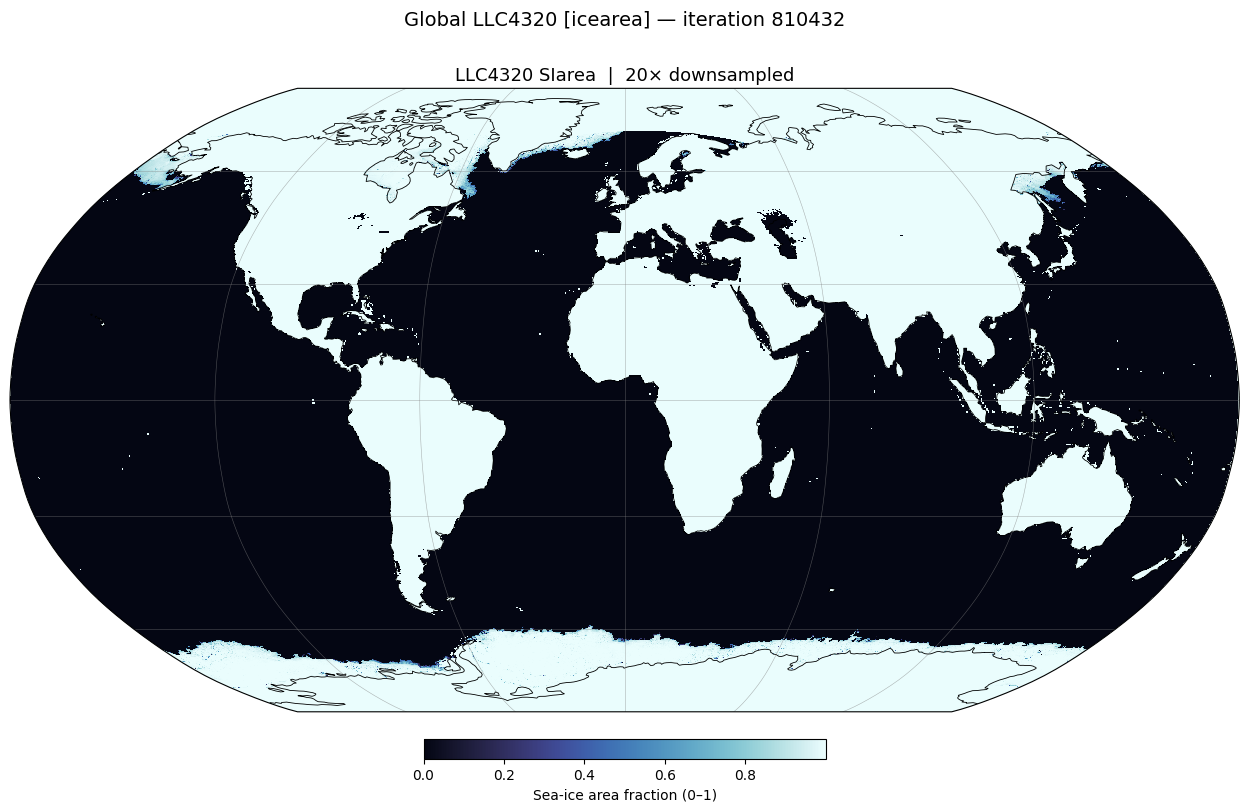

In [18]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
target   = channels_to_plot[0]
timestep = 0
# ════════════════════════════════════════════════════════════════════════════════

arr_ds = reader.get_channel_snapshot(target)[::DS_GLOBAL, ::DS_GLOBAL]

fig = plt.figure(figsize=(16, 8))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

im, label = plot_global_field(
    ax, XC_g, YC_g, arr_ds, target, CMAP_CFG,
    log_scale_channels=LOG_SCALE_CHANNELS,
    diverging_cmaps=DIVERGING_CMAPS,
    percentiles=(1, 99),
    transform=ccrs.PlateCarree(),
)
ax.gridlines(linewidth=0.4, color='gray', alpha=0.6)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, shrink=0.7,
             label=label, orientation='horizontal')
ax.set_title(
    f'LLC4320 {target}  |  {DS_GLOBAL}× downsampled',
    fontsize=13,
)
plt.suptitle(
    f'Global LLC4320 [{SUBSET}] — iteration {reader.iteration}',
    fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()

## All-channels global overview

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
timestep = 0
ncols    = 3
# ════════════════════════════════════════════════════════════════════════════════

nrows = int(np.ceil(len(channels_to_plot) / ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 7, nrows * 4),
    subplot_kw={'projection': ccrs.Robinson()},
)
axes = np.array(axes).flatten()

for ax, ch in zip(axes, channels_to_plot):
    arr = reader.get_channel_snapshot(ch)[::DS_GLOBAL, ::DS_GLOBAL]
    im, label = plot_global_field(
        ax, XC_g, YC_g, arr, ch, CMAP_CFG,
        log_scale_channels=LOG_SCALE_CHANNELS,
        diverging_cmaps=DIVERGING_CMAPS,
        percentiles=(2, 98),
        transform=ccrs.PlateCarree(),
        coastline_kw={'linewidth': 0.4, 'edgecolor': 'k'},
    )
    if im is None:
        ax.set_visible(False)
        continue
    ax.set_title(label, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85,
                 orientation='horizontal')

for ax in axes[len(channels_to_plot):]:
    ax.set_visible(False)

plt.suptitle(
    f'Global LLC4320 [{SUBSET}]  |  '
    f'iteration {reader.iteration}  |  {DS_GLOBAL}× downsampled',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## Compare depth variants of the same field

For fields with `_sfc`, `_z25m`, `_mld`, `_mld_mean` suffixes, plot all four
side by side to see how the field varies across depth definitions.

*Skip this cell if the current subset has no depth suffixes.*

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
# Set BASE_FIELD to any field that has _sfc/_z25m/_mld/_mld_mean variants.
# Examples: 'N2', 'vertical_shear', 'Ri', 'Fr', 'Ro', 'ertel_pv',
#           'ertel_pv_vertical', 'ertel_pv_tilt', 'uB', 'vB', 'wB', 'KE'
BASE_FIELD = 'N2'
timestep   = 0
# ════════════════════════════════════════════════════════════════════════════════

depth_suffixes_plot = ['sfc', 'z25m', 'mld', 'mld_mean']
variant_channels = [f"{BASE_FIELD}_{s}" for s in depth_suffixes_plot]
available = [ch for ch in variant_channels if ch in reader.channel_names]

if not available:
    print(f"No depth variants found for '{BASE_FIELD}' in this subset.")
    print(f"Available channels: {reader.channel_names}")
else:
    ncols_v = len(available)
    fig, axes = plt.subplots(
        1, ncols_v,
        figsize=(ncols_v * 6, 5),
        subplot_kw={'projection': ccrs.Robinson()},
    )
    if ncols_v == 1:
        axes = [axes]

    for ax, ch in zip(axes, available):
        arr = reader.get_channel_snapshot(ch)[::DS_GLOBAL, ::DS_GLOBAL]
        im, label = plot_global_field(
            ax, XC_g, YC_g, arr, ch, CMAP_CFG,
            log_scale_channels=LOG_SCALE_CHANNELS,
            diverging_cmaps=DIVERGING_CMAPS,
            percentiles=(2, 98),
            transform=ccrs.PlateCarree(),
            coastline_kw={'linewidth': 0.4, 'edgecolor': 'k'},
        )
        if im is None:
            ax.set_visible(False)
            continue
        ax.set_title(label, fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85,
                     orientation='horizontal')

    plt.suptitle(
        f'{BASE_FIELD} depth variants  |  iteration {reader.iteration}  |  {DS_GLOBAL}× downsampled',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()

## Per-channel statistics

Quick sanity check: min/max/mean/NaN fraction for each channel.

In [ ]:
timestep = 0
print(f"{'Channel':<30s}  {'Min':>12s}  {'Max':>12s}  {'Mean':>12s}  {'NaN %':>7s}")
print("\u2500" * 80)
for ch in reader.channel_names:
    arr = reader.get_channel_snapshot(ch)
    finite = arr[np.isfinite(arr)]
    nan_pct = 100.0 * (1.0 - finite.size / arr.size)
    if finite.size > 0:
        print(f"{ch:<30s}  {finite.min():>12.4g}  {finite.max():>12.4g}  {finite.mean():>12.4g}  {nan_pct:>6.1f}%")
    else:
        print(f"{ch:<30s}  {'all NaN':>12s}  {'':>12s}  {'':>12s}  {nan_pct:>6.1f}%")

## Regional plots

### Region selection by lat/lon

The grid (XC, YC) is loaded \u2014 you can select any region by geographic
coordinates.  The nearest pixel to your requested **(lat, lon)** centre is
found automatically, and the bounding box is derived from an approximate
km-to-pixel conversion (LLC4320 native resolution \u2248 1/48\u00b0 \u2248 2.3 km at
mid-latitudes).

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS \u2014 edit these to choose your region
# ════════════════════════════════════════════════════════════════════════════════
LAT_CENTER = 36.0       # degrees north
LON_CENTER = -72.0      # degrees east  (use negative for west)
HALF_H_KM  = 1000.0     # approximate half-height of region (km)
HALF_W_KM  = 2000.0     # approximate half-width  of region (km)
# ════════════════════════════════════════════════════════════════════════════════

H, W = reader.rectangular_shape

lon_q = LON_CENTER % 360 if float(XC.max()) > 180 else LON_CENTER

dist = np.sqrt((XC - lon_q) ** 2 + (YC - LAT_CENTER) ** 2)
cy, cx = np.unravel_index(int(np.nanargmin(dist)), dist.shape)
print(f"Nearest pixel to ({LAT_CENTER}\u00b0N, {LON_CENTER}\u00b0E): y={cy}, x={cx}  "
      f"[actual: lat={float(YC[cy,cx]):.3f}\u00b0N, lon={float(XC[cy,cx]):.3f}\u00b0E]")

KM_PER_PIX = 2.3
HALF_H_PIX = int(HALF_H_KM / KM_PER_PIX)
HALF_W_PIX = int(HALF_W_KM / KM_PER_PIX)

y0 = max(0, cy - HALF_H_PIX)
y1 = min(H, cy + HALF_H_PIX)
x0 = max(0, cx - HALF_W_PIX)
x1 = min(W, cx + HALF_W_PIX)

XC_reg = XC[y0:y1, x0:x1]
YC_reg = YC[y0:y1, x0:x1]

print(f"Region: rows [{y0}:{y1}], cols [{x0}:{x1}]  ->  {y1-y0} x {x1-x0} pixels")
print(f"Geographic extent: lon [{float(XC_reg.min()):.2f}, {float(XC_reg.max()):.2f}]  "
      f"lat [{float(YC_reg.min()):.2f}, {float(YC_reg.max()):.2f}]")

In [ ]:
# ── Global context map with selected region outlined ──────────────────────────
context_ch = channels_to_plot[0]
ctx_ds = reader.get_channel_snapshot(context_ch)[::DS_GLOBAL, ::DS_GLOBAL]

fig = plt.figure(figsize=(18, 9))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

im, ctx_label = plot_global_field(
    ax, XC_g, YC_g, ctx_ds, context_ch, CMAP_CFG,
    log_scale_channels=LOG_SCALE_CHANNELS,
    diverging_cmaps=DIVERGING_CMAPS,
    percentiles=(2, 98),
    transform=ccrs.PlateCarree(),
    coastline_kw={'linewidth': 0.6, 'edgecolor': 'k'},
)
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04, shrink=0.7,
             label=ctx_label, orientation='horizontal')
ax.gridlines(linewidth=0.4, color='gray', alpha=0.5)

pc = ccrs.PlateCarree()
ax.plot(XC[y0, x0:x1],   YC[y0, x0:x1],   'r-', lw=2, transform=pc)
ax.plot(XC[y1-1, x0:x1], YC[y1-1, x0:x1], 'r-', lw=2, transform=pc)
ax.plot(XC[y0:y1, x0],   YC[y0:y1, x0],   'r-', lw=2, transform=pc)
ax.plot(XC[y0:y1, x1-1], YC[y0:y1, x1-1], 'r-', lw=2, transform=pc)
ax.plot(float(XC[cy, cx]), float(YC[cy, cx]),
        'r+', markersize=14, markeredgewidth=2.5, transform=pc, zorder=6)

ax.set_title(
    f'Global [{SUBSET}] — {context_ch} ({DS_GLOBAL}× downsampled) — selected region (red box)\n'
    f'centre: ({LAT_CENTER}°N, {LON_CENTER}°E)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [ ]:
# ── Regional subplots — all channels ──────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
timestep = 0
ncols    = 3
# ════════════════════════════════════════════════════════════════════════════════

nrows = int(np.ceil(len(channels_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 6))
axes = np.array(axes).flatten()

for ax, ch in zip(axes, channels_to_plot):
    arr = reader.get_channel_snapshot(ch)[y0:y1, x0:x1]
    im, label = plot_global_field(
        ax, XC_reg, YC_reg, arr, ch, CMAP_CFG,
        log_scale_channels=LOG_SCALE_CHANNELS,
        diverging_cmaps=DIVERGING_CMAPS,
        percentiles=(1, 99),
        transform=None,
        add_coastline=False,
    )
    if im is None:
        ax.set_visible(False)
        continue
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Longitude (°E)', fontsize=9)
    ax.set_ylabel('Latitude (°N)',  fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9)

for ax in axes[len(channels_to_plot):]:
    ax.set_visible(False)

plt.suptitle(
    f'Regional [{SUBSET}]  |  '
    f'centre ({LAT_CENTER}°N, {LON_CENTER}°E)  |  '
    f'lon [{float(XC_reg.min()):.1f}°, {float(XC_reg.max()):.1f}°]  '
    f'lat [{float(YC_reg.min()):.1f}°, {float(YC_reg.max()):.1f}°]',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()